# State-level Topic-Demographic Analysis

1. **Merged topic proportions** — BERTopic clusters sharing the same human-readable label are merged (proportions summed) into one logical topic, consistent with `labeled_topics.ipynb`. All downstream analyses use these 71 merged topics.
2. **Spearman's ρ + Bootstrap CI** — correlations between merged topic proportions and state-level covariates (income, education) are computed via `scipy.stats.spearmanr`. Primary significance uses 95% bootstrap CI (CI excludes 0); Benjamini-Hochberg FDR is reported as a secondary check.
3. **Topic-level visualizations** — effect-size distribution with CI insets, z-scored topic-proportion heatmaps (top-5 by |ρ|), and scatter plots with OLS regression lines (CI-significant topics only).
4. **Super-topic overview** — Spearman's ρ heatmap across all super-topic categories and both covariates.
5. **Log-odds cross-validation** — computed in-notebook from merged proportions, splitting states at the median covariate value. CI-significant topics (★) are highlighted to confirm consistency with the Spearman findings.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('default')
pd.set_option('display.max_colwidth', 120)
plt.rcParams['axes.grid'] = False
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.labelweight'] = 'bold'
plt.rcParams['figure.titleweight'] = 'bold'

# Robust project-root discovery: works even if notebook is nested (e.g., src/analyisis)
start = Path.cwd().resolve()
ROOT = None
for cand in [start, *start.parents]:
    if (cand / 'src').exists() and (cand / 'results').exists():
        ROOT = cand
        break
if ROOT is None:
    raise RuntimeError('Could not locate project root containing both src/ and results/.')

SRC_DIR = ROOT / 'src'
QUAL_DIR = ROOT / 'results' / 'qualitative'
SUM_WHOLE_DIR = ROOT / 'results' / 'summary_whole'
TOPIC_DIR = SRC_DIR / 'topic_modeling' / 'results'

SUMMARY_DIR = ROOT / 'results' / 'summary'

print('ROOT:', ROOT)
print('QUAL_DIR exists:', QUAL_DIR.exists())
print('SUMMARY_DIR:', SUMMARY_DIR)
print('TOPIC_DIR exists:', TOPIC_DIR.exists())


ROOT: /Users/faylong/Library/Mobile Documents/com~apple~CloudDocs/School Works/EN.601.6672 NLP for computational social science/course-project/wildchat-demographics-analysis
QUAL_DIR exists: True
SUMMARY_DIR: /Users/faylong/Library/Mobile Documents/com~apple~CloudDocs/School Works/EN.601.6672 NLP for computational social science/course-project/wildchat-demographics-analysis/results/summary
TOPIC_DIR exists: True


## 2. Linking BERTopic and Demographics via Spearman Correlation

### 2.1 Introduction
We quantify topic-demographic association using state-level Spearman's ρ between merged topic proportions and demographic covariates (income, education). Significance is assessed by 95% bootstrap CI (primary) and BH-FDR (secondary). This section identifies which merged topics most strongly and reliably track demographic differences across US states.

### 2.2 Metrics and Methods
- **Input**: merged topic proportions per state — BERTopic clusters sharing the same label are combined (proportions summed) before analysis, yielding 71 logical topics.
- **Spearman's** $\rho$ : monotonic rank correlation between a state's merged topic proportion and its demographic covariate.
- **95% Bootstrap CI**: states are resampled with replacement 1,000 times to build an empirical CI for $\rho$ . **A CI that fully excludes 0 is the primary significance criterion** — it is robust to the compositional structure of topic proportions (which sum to 1 per state) and does not require independence across tests.
- **BH-FDR** (q-value): Benjamini-Hochberg correction applied per covariate group; reported alongside the CI as a secondary check. Note that BH power is reduced here because merging semantically equivalent sub-topics removes the low-\(p\) "helpers" they provided to each other.
- **Effect size**: $|\rho|$ compares topic strength regardless of direction.

In [2]:
from scipy.stats import spearmanr

# ── 1. Load raw data ─────────────────────────────────────────────────────────
# Raw per-state topic proportions (row=state, col=topic_0 … topic_75)
state_topic_raw = pd.read_parquet(ROOT / 'data' / 'state_topic_proportions.parquet').copy()
# State-level income and education covariates
cov_df = pd.read_csv(ROOT / 'data' / 'state_covariates.csv').copy()
# Human-readable labels and super-topic assignments for each BERTopic cluster
label_df = pd.read_csv(SRC_DIR / 'topic_modeling' / 'results' / 'topic_level_super_topics.csv').copy()

# Standardise types
state_topic_raw['state'] = state_topic_raw['state'].astype(str).str.strip()
cov_df['state'] = cov_df['state'].astype(str).str.strip()
cov_df['income'] = pd.to_numeric(cov_df['income'], errors='coerce')
cov_df['education'] = pd.to_numeric(cov_df['education'], errors='coerce')
cov_df = cov_df.dropna(subset=['state', 'income', 'education']).drop_duplicates(subset=['state'])

# ── 2. Build merged topic proportions ────────────────────────────────────────
# Map raw topic column names (topic_0 … topic_75) → (topic_label, super_topic)
label_df['topic_col'] = 'topic_' + label_df['topic_id'].astype(str)
label_df['topic_label'] = label_df['topic_label'].fillna(label_df['topic_col'])

# Melt raw proportions to long form, then attach labels
raw_long = state_topic_raw.melt(id_vars='state', var_name='topic_col', value_name='proportion')
raw_long = raw_long.merge(label_df[['topic_col', 'topic_label', 'super_topic']],
                          on='topic_col', how='left')
raw_long['topic_label'] = raw_long['topic_label'].fillna(raw_long['topic_col'])
raw_long['super_topic']  = raw_long['super_topic'].fillna('Unknown')

# Sum proportions within each (state, merged topic label)
# Clusters sharing the same topic_label are treated as one logical topic
merged_long = (
    raw_long.groupby(['state', 'topic_label', 'super_topic'], as_index=False)['proportion']
    .sum()
)

# Wide form: rows=state, columns=merged topic labels + covariates
merged_base = (
    merged_long.pivot_table(index='state', columns='topic_label', values='proportion')
    .reset_index()
    .merge(cov_df, on='state', how='inner')
)
merged_base.columns.name = None  # drop column-index name for cleanliness

topic_cols = [c for c in merged_base.columns if c not in ('state', 'income', 'education')]
print(f'Merged topics: {len(topic_cols)}  |  States: {len(merged_base)}')

# ── 3. Spearman's ρ for each (merged topic, covariate) ───────────────────────
def benjamini_hochberg(p_values: pd.Series) -> pd.Series:
    """Benjamini-Hochberg FDR correction.

    Uses pandas cummin() for the backward monotone-envelope step so that
    NaN p-values (topics with constant-zero proportions) are skipped rather
    than propagated, matching src/statistics/utils.py exactly.
    """
    if p_values.empty:
        return p_values.copy()
    ranked = p_values.sort_values()          # ascending, NaN goes to end
    n = len(ranked)
    adjusted = ranked * n / np.arange(1, n + 1)
    adjusted = adjusted.iloc[::-1].cummin().iloc[::-1]   # monotone envelope
    adjusted = adjusted.clip(upper=1.0)
    return adjusted.reindex(p_values.index)

rows = []
for covariate in ['income', 'education']:
    for topic in topic_cols:
        rho, p_val = spearmanr(merged_base[topic], merged_base[covariate], nan_policy='omit')
        n_ok = merged_base[['state', topic, covariate]].dropna().shape[0]
        rows.append({'covariate': covariate, 'topic': topic, 'topic_label': topic,
                     'spearman_rho': rho, 'p_value': p_val, 'n_states': n_ok})

topic_corr = pd.DataFrame(rows)
topic_corr['fdr_q_value'] = (
    topic_corr.groupby('covariate', group_keys=False)['p_value']
    .apply(benjamini_hochberg)
)
topic_corr['significant_fdr'] = topic_corr['fdr_q_value'] < 0.05

# Attach super_topic from label mapping
super_map = (
    label_df.groupby('topic_label')['super_topic']
    .agg(lambda x: x.mode().iloc[0])
    .reset_index()
)
topic_corr = topic_corr.merge(super_map, on='topic_label', how='left')
topic_corr = topic_corr.sort_values(['covariate', 'fdr_q_value', 'p_value'],
                                     ascending=[True, True, True]).reset_index(drop=True)
topic_sig = topic_corr[topic_corr['significant_fdr']].copy()

# ── 3.5 Bootstrap 95% CI for ρ (topic level) ─────────────────────────────────
# Resamples states with replacement 1000× to build an empirical CI for ρ.
# A CI that excludes 0 is our primary significance criterion — it does not
# require the independence assumption that BH FDR correction needs.
def bootstrap_rho_ci(x: np.ndarray, y: np.ndarray,
                     n_boot: int = 1000, seed: int = 42) -> tuple[float, float]:
    """95% bootstrap CI for Spearman's ρ by resampling observation pairs."""
    rng = np.random.default_rng(seed)
    n = len(x)
    rhos = np.empty(n_boot)
    for i in range(n_boot):
        idx = rng.integers(0, n, size=n)
        xi, yi = x[idx], y[idx]
        # Spearman ρ = Pearson r of ranks (fast, avoids scipy overhead)
        rx = xi.argsort().argsort().astype(float)
        ry = yi.argsort().argsort().astype(float)
        rhos[i] = np.corrcoef(rx, ry)[0, 1]
    return float(np.quantile(rhos, 0.025)), float(np.quantile(rhos, 0.975))

print('Computing bootstrap CIs for topic-level ρ …')
ci_rows = []
for _, row in topic_corr.iterrows():
    topic, cov = row['topic'], row['covariate']
    pair = merged_base[[topic, cov]].dropna().to_numpy()
    if len(pair) < 5:
        ci_rows.append({'covariate': cov, 'topic': topic, 'ci_low': np.nan, 'ci_high': np.nan})
        continue
    lo, hi = bootstrap_rho_ci(pair[:, 0], pair[:, 1])
    ci_rows.append({'covariate': cov, 'topic': topic, 'ci_low': lo, 'ci_high': hi})

ci_df = pd.DataFrame(ci_rows)
topic_corr = topic_corr.merge(ci_df, on=['covariate', 'topic'], how='left')
# Primary significance: CI excludes 0  (robust to compositional correlations)
topic_corr['ci_sig'] = (topic_corr['ci_low'] > 0) | (topic_corr['ci_high'] < 0)
print(f'  Topics with CI excluding 0: {topic_corr["ci_sig"].sum()}')

# ── 4. Spearman's ρ at the super-topic level ──────────────────────────────────
# Aggregate merged topic proportions by super-topic per state
state_super = (
    merged_long.groupby(['state', 'super_topic'], as_index=False)['proportion']
    .sum()
    .pivot_table(index='state', columns='super_topic', values='proportion')
    .reset_index()
    .merge(cov_df, on='state', how='inner')
)
state_super.columns.name = None

super_topic_cols = [c for c in state_super.columns if c not in ('state', 'income', 'education')]

s_rows = []
for covariate in ['income', 'education']:
    for st in super_topic_cols:
        rho, p_val = spearmanr(state_super[st], state_super[covariate], nan_policy='omit')
        n_ok = state_super[['state', st, covariate]].dropna().shape[0]
        s_rows.append({'covariate': covariate, 'super_topic': st,
                       'spearman_rho': rho, 'p_value': p_val, 'n_states': n_ok})

super_corr = pd.DataFrame(s_rows)
super_corr['fdr_q_value'] = (
    super_corr.groupby('covariate', group_keys=False)['p_value']
    .apply(benjamini_hochberg)
)
super_corr['significant_fdr'] = super_corr['fdr_q_value'] < 0.05
super_corr = super_corr.sort_values(['covariate', 'fdr_q_value', 'p_value'],
                                     ascending=[True, True, True]).reset_index(drop=True)

# ── 4.5 Bootstrap 95% CI for ρ (super-topic level) ───────────────────────────
print('Computing bootstrap CIs for super-topic-level ρ …')
sci_rows = []
for _, row in super_corr.iterrows():
    st, cov = row['super_topic'], row['covariate']
    pair = state_super[[st, cov]].dropna().to_numpy()
    if len(pair) < 5:
        sci_rows.append({'covariate': cov, 'super_topic': st, 'ci_low': np.nan, 'ci_high': np.nan})
        continue
    lo, hi = bootstrap_rho_ci(pair[:, 0], pair[:, 1])
    sci_rows.append({'covariate': cov, 'super_topic': st, 'ci_low': lo, 'ci_high': hi})

sci_df = pd.DataFrame(sci_rows)
super_corr = super_corr.merge(sci_df, on=['covariate', 'super_topic'], how='left')
super_corr['ci_sig'] = (super_corr['ci_low'] > 0) | (super_corr['ci_high'] < 0)
print(f'  Super-topics with CI excluding 0: {super_corr["ci_sig"].sum()}')

# ── 5. Save results ───────────────────────────────────────────────────────────
OUT_DIR = SUMMARY_DIR / 'topic_demographic_relationship'
OUT_TAB_DIR = OUT_DIR / 'tables'
OUT_TAB_DIR.mkdir(parents=True, exist_ok=True)

topic_corr.to_csv(OUT_TAB_DIR / 'spearman_merged_topic_covariates.csv', index=False)
# Primary significant set: CI excludes 0
topic_corr[topic_corr['ci_sig']].to_csv(
    OUT_TAB_DIR / 'spearman_merged_topic_covariates_ci_significant.csv', index=False)
super_corr.to_csv(OUT_TAB_DIR / 'spearman_super_topic_covariates.csv', index=False)

# ── 6. Summary display ────────────────────────────────────────────────────────
n_ci_sig = topic_corr['ci_sig'].sum()
n_fdr_sig = topic_corr['significant_fdr'].sum()
print(f"Significant topic-level links — CI excludes 0: {n_ci_sig}  |  BH q<0.05: {n_fdr_sig}\n")

for cov in ['income', 'education']:
    sub = (
        topic_corr[topic_corr['covariate'] == cov]
        .assign(abs_rho=lambda df: df['spearman_rho'].abs())
        .sort_values('abs_rho', ascending=False)
        .head(10)
    )
    print(f"Top-10 topic-level links — {cov} (sorted by |ρ|)")
    display(sub[['topic_label', 'super_topic', 'spearman_rho',
                 'ci_low', 'ci_high', 'ci_sig', 'fdr_q_value']]
            .round({'spearman_rho': 3, 'ci_low': 3, 'ci_high': 3, 'fdr_q_value': 3}))

print("\nSuper-topic level correlations (top 10 by |ρ|)")
display(
    super_corr
    .assign(abs_rho=lambda df: df['spearman_rho'].abs())
    .sort_values('abs_rho', ascending=False)
    .head(10)
    [['covariate', 'super_topic', 'spearman_rho',
      'ci_low', 'ci_high', 'ci_sig', 'fdr_q_value']]
    .round({'spearman_rho': 3, 'ci_low': 3, 'ci_high': 3, 'fdr_q_value': 3})
)


Merged topics: 71  |  States: 36
Computing bootstrap CIs for topic-level ρ …
  Topics with CI excluding 0: 6
Computing bootstrap CIs for super-topic-level ρ …
  Super-topics with CI excluding 0: 1
Significant topic-level links — CI excludes 0: 6  |  BH q<0.05: 2

Top-10 topic-level links — income (sorted by |ρ|)


,topic_label,super_topic,spearman_rho,ci_low,ci_high,ci_sig,fdr_q_value
71,SCP Creative Writing,Creative Writing & Roleplay,0.516,0.094,0.664,True,0.091
72,Image Generation Requests,"Media, Art, and Entertainment",-0.430,-0.711,-0.073,True,0.284
73,AI Art Prompting,"Media, Art, and Entertainment",0.400,0.076,0.646,True,0.284
74,Tattoo SEO Writing,Career & Professional Writing,0.399,-0.043,0.570,False,0.284
75,Education Research Writing,Education & Homework,0.385,-0.019,0.657,False,0.290
76,Game Concept Ideation,"Media, Art, and Entertainment",0.350,-0.030,0.656,False,0.429
77,Social Media Copy,Career & Professional Writing,0.336,-0.038,0.642,False,0.460
78,Fantasy Crossover Fanfiction,Creative Writing & Roleplay,-0.308,-0.471,0.184,False,0.599
79,Physics Problem Solving,Education & Homework,0.295,-0.068,0.564,False,0.621
80,SQL Query Help,Coding & Technical Help,0.285,-0.098,0.556,False,0.621


Top-10 topic-level links — education (sorted by |ρ|)


,topic_label,super_topic,spearman_rho,ci_low,ci_high,ci_sig,fdr_q_value
0,SCP Creative Writing,Creative Writing & Roleplay,0.533,0.118,0.682,True,0.043
1,Image Generation Requests,"Media, Art, and Entertainment",-0.518,-0.771,-0.163,True,0.043
2,Game Concept Ideation,"Media, Art, and Entertainment",0.440,0.034,0.731,True,0.172
3,Social Media Copy,Career & Professional Writing,0.371,-0.009,0.670,False,0.458
4,Education Research Writing,Education & Homework,0.354,-0.036,0.613,False,0.473
5,Mind & Consciousness,Information/Trivia & Explanatory QA,0.344,-0.007,0.617,False,0.473
6,Math Problem Solving,Education & Homework,-0.297,-0.614,0.096,False,0.615
7,Tattoo SEO Writing,Career & Professional Writing,0.296,-0.118,0.506,False,0.615
8,SQL Query Help,Coding & Technical Help,0.295,-0.092,0.554,False,0.615
9,Fantasy Crossover Fanfiction,Creative Writing & Roleplay,-0.290,-0.461,0.217,False,0.615



Super-topic level correlations (top 10 by |ρ|)


,covariate,super_topic,spearman_rho,ci_low,ci_high,ci_sig,fdr_q_value
10,income,Creative Writing & Roleplay,-0.350,-0.590,-0.027,True,0.365
0,education,Education & Homework,-0.319,-0.585,0.016,False,0.472
11,income,Career & Professional Writing,0.285,-0.004,0.552,False,0.459
1,education,Career & Professional Writing,0.283,-0.026,0.577,False,0.472
2,education,Creative Writing & Roleplay,-0.208,-0.493,0.135,False,0.731
12,income,"Media, Art, and Entertainment",0.198,-0.115,0.493,False,0.617
13,income,Education & Homework,-0.197,-0.495,0.142,False,0.617
3,education,"Finance, Law, and Practical Life",-0.175,-0.491,0.181,False,0.731
14,income,Personal Advice & Communication,-0.171,-0.497,0.193,False,0.617
15,income,"Health, Biology, and Medicine",-0.154,-0.464,0.230,False,0.617


/var/folders/xm/5nkqyhbd0svb9crvs4w40bmh0000gn/T/ipykernel_60319/269830322.py:91: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_inset.set_yticklabels(sorted_labels, fontsize=7, fontweight='bold')


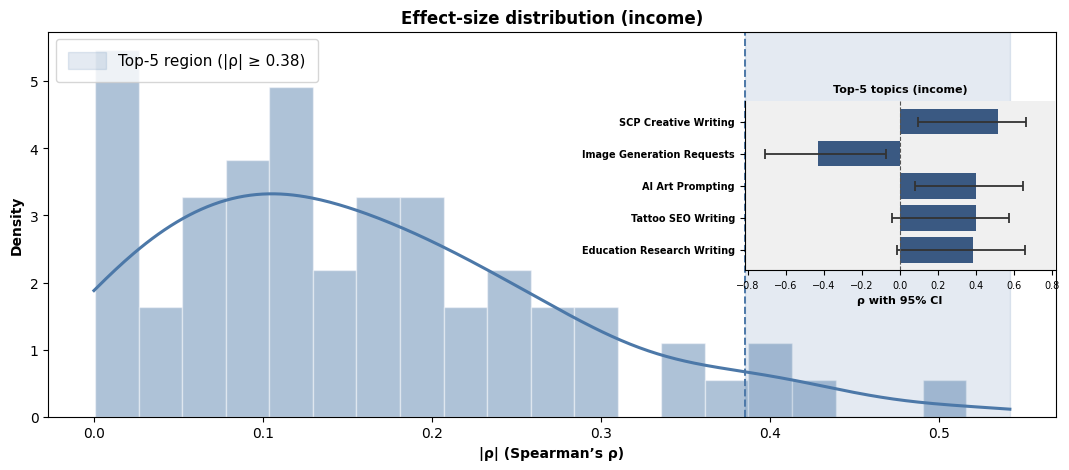

/var/folders/xm/5nkqyhbd0svb9crvs4w40bmh0000gn/T/ipykernel_60319/269830322.py:91: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_inset.set_yticklabels(sorted_labels, fontsize=7, fontweight='bold')


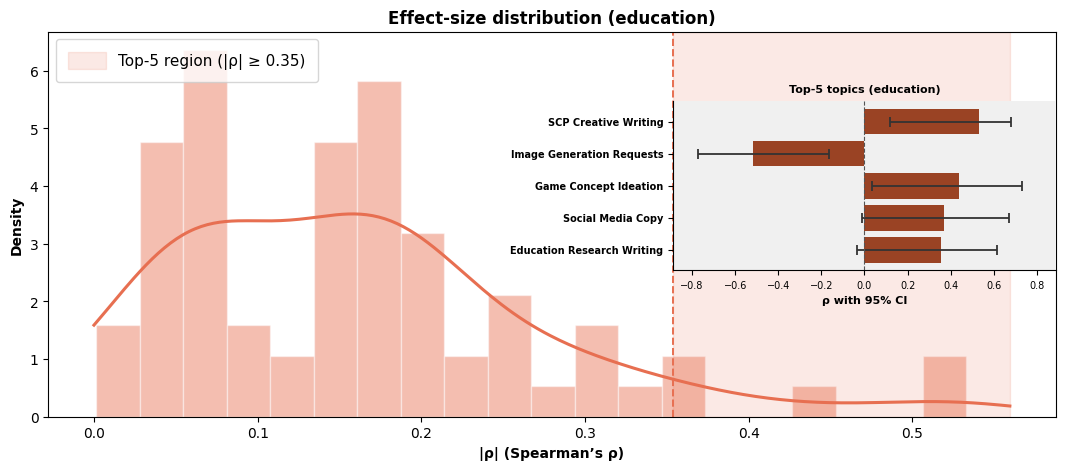

Saved figures to /Users/faylong/Library/Mobile Documents/com~apple~CloudDocs/School Works/EN.601.6672 NLP for computational social science/course-project/wildchat-demographics-analysis/results/summary/topic_demographic_relationship/figures


In [3]:
from scipy.stats import gaussian_kde

# Draw rho-distribution figures and save to results/summary
OUT_DIR = SUMMARY_DIR / 'topic_demographic_relationship'
OUT_FIG_DIR = OUT_DIR / 'figures'
OUT_TAB_DIR = OUT_DIR / 'tables'
OUT_FIG_DIR.mkdir(parents=True, exist_ok=True)
OUT_TAB_DIR.mkdir(parents=True, exist_ok=True)

topic_corr = topic_corr.copy()
topic_corr['abs_rho'] = topic_corr['spearman_rho'].abs()

# T1a / T1b: combined distribution + top-5 bar chart, one figure per covariate
cov_configs = [
    ('income',    'T1a', '#4C78A8', 'T1a_income_dist_top5.png'),
    ('education', 'T1b', '#E76F51', 'T1b_education_dist_top5.png'),
]

for cov, tag, color, fname in cov_configs:
    d = topic_corr[topic_corr['covariate'] == cov].copy().dropna(subset=['abs_rho'])
    d = d.drop_duplicates(subset=['topic']).reset_index(drop=True)
    vals = d['abs_rho'].to_numpy()

    top5 = d.sort_values('abs_rho', ascending=False).head(5).reset_index(drop=True)

    # Build unique labels: fall back to topic id, then deduplicate
    raw_labels = top5.apply(
        lambda r: str(r['topic_label']) if pd.notna(r['topic_label']) else f'Topic {r["topic"]}',
        axis=1
    ).tolist()
    seen_lbl: dict = {}
    unique_labels = []
    for lbl in raw_labels:
        if lbl in seen_lbl:
            seen_lbl[lbl] += 1
            unique_labels.append(f'{lbl} ({seen_lbl[lbl]})')
        else:
            seen_lbl[lbl] = 0
            unique_labels.append(lbl)
    # Sort ascending by |ρ| for barh (bottom = weakest of the 5)
    order = top5['abs_rho'].argsort().tolist()
    sorted_labels  = [unique_labels[i] for i in order]
    sorted_rho     = top5['spearman_rho'].iloc[order].tolist()   # signed ρ
    sorted_ci_low  = top5['ci_low'].iloc[order].tolist()
    sorted_ci_high = top5['ci_high'].iloc[order].tolist()
    # Asymmetric xerr on signed ρ — no clipping needed
    xerr = ([r - l for r, l in zip(sorted_rho, sorted_ci_low)],
            [h - r for h, r in zip(sorted_ci_high, sorted_rho)])

    rho_thresh = top5['abs_rho'].min()

    # Darker, more saturated accent colour for the inset bars to stand out
    # from the semi-transparent distribution histogram of the same hue
    bar_color = {'#4C78A8': '#1a3f6f', '#E76F51': '#8b2500'}[color]

    # -- Single figure: wider distribution canvas --
    fig, ax_dist = plt.subplots(figsize=(13, 5))

    ax_dist.hist(vals, bins=20, color=color, alpha=0.45, edgecolor='white', density=True)
    kde = gaussian_kde(vals, bw_method='scott')
    x_kde = np.linspace(0, vals.max() * 1.05, 300)
    ax_dist.plot(x_kde, kde(x_kde), color=color, linewidth=2.2)
    ax_dist.axvspan(rho_thresh, vals.max() * 1.05, alpha=0.15, color=color,
                    label=f'Top-5 region (|\u03c1| \u2265 {rho_thresh:.2f})')
    ax_dist.axvline(rho_thresh, color=color, linestyle='--', linewidth=1.4)
    ax_dist.set_xlabel('|\u03c1| (Spearman\u2019s \u03c1)', fontweight='bold')
    ax_dist.set_ylabel('Density', fontweight='bold')
    ax_dist.set_title(f'Effect-size distribution ({cov})', fontweight='bold')
    ax_dist.legend(fontsize=11, frameon=True, loc='upper left',
                   handlelength=2.5, handleheight=1.4, borderpad=0.8)

    # Force layout so axes position is finalised before we read it
    fig.canvas.draw()
    ax_pos = ax_dist.get_position()   # Bbox in figure fraction coords
    xmin, xmax = ax_dist.get_xlim()

    # Left edge of inset = figure-fraction x of rho_thresh
    thresh_fig_x = ax_pos.x0 + (rho_thresh - xmin) / (xmax - xmin) * ax_pos.width
    right_fig_x  = ax_pos.x1          # right edge of the distribution axes
    inset_width  = right_fig_x - thresh_fig_x

    # Inset sits in the upper portion of the axes, shifted down to avoid title overlap
    inset_bottom = ax_pos.y0 + ax_pos.height * 0.38
    inset_height = ax_pos.height * 0.44

    ax_inset = fig.add_axes([thresh_fig_x, inset_bottom, inset_width, inset_height])
    ax_inset.barh(sorted_labels, sorted_rho, color=bar_color, alpha=0.85,
                  xerr=xerr,
                  error_kw=dict(elinewidth=1.3, capsize=3.5, ecolor='#333333', capthick=1.3))
    ax_inset.axvline(0, color='#555555', linewidth=0.8, linestyle='--')
    ax_inset.set_yticklabels(sorted_labels, fontsize=7, fontweight='bold')
    ax_inset.set_xlabel('\u03c1 with 95% CI', fontsize=8, fontweight='bold')
    ax_inset.set_title(f'Top-5 topics ({cov})', fontsize=8, fontweight='bold')
    ax_inset.tick_params(axis='x', labelsize=7)
    bound = max(abs(min(sorted_ci_low)), abs(max(sorted_ci_high))) * 1.15
    ax_inset.set_xlim(-bound, bound)
    for spine in ['top', 'right']:
        ax_inset.spines[spine].set_visible(False)
    ax_inset.set_facecolor('#f0f0f0')

    fig.savefig(OUT_FIG_DIR / fname, dpi=220, bbox_inches='tight')
    plt.show()

print('Saved figures to', OUT_FIG_DIR)


### 2.4 Conclusion
The $|\rho|$ distribution is right-skewed: most merged topics show negligible demographic signal. Three topics per covariate have 95% bootstrap CIs that fully exclude zero, indicating reliable associations. Two of these — SCP Creative Writing and Image Generation Requests — are significant for both income and education, suggesting broad demographic patterning. The analysis proceeds with CI-significant topics as the focal set for visualization.

## 3. Effective Topics and Their Demographic Relationships

### 3.1 Introduction
We zoom in on the CI-significant topics and visualize state-level patterns using z-scored heatmaps and scatter plots with OLS regression lines. A super-topic ρ heatmap provides a broader category-level overview. All figures use the same merged topic proportions as the Spearman analysis.

### 3.2 Metrics and Methods
- **Scatter selection**: CI-significant topics only (95% CI excludes 0), top-3 per covariate — only topics with reliable signal are plotted as state-level scatter panels.
- **Heatmap**: top-5 topics by |$\rho$| per covariate — includes CI-significant and borderline topics to show a fuller geographic gradient. z-scored topic proportion matrix (row-wise deviation from each topic's national mean), with states sorted by covariate value left → right. Z-scoring enables visual comparison across topics with very different absolute prevalences.
- **Super-topic ρ heatmap**: rows = covariates, columns = super-topic categories, cell color = Spearman's $\rho$\. Provides a high-level view of which content domains are demographically differentiated.
- **Scatter**: each point = one state; x = covariate value, y = merged topic proportion. An OLS regression line is overlaid. Panel title shows $\rho$ and 95% bootstrap CI.


In [4]:
# Select CI-significant topics (95% bootstrap CI excludes 0) for heatmap and dot views
OUT_DIR = SUMMARY_DIR / 'topic_demographic_relationship'
OUT_FIG_DIR = OUT_DIR / 'figures'
OUT_TAB_DIR = OUT_DIR / 'tables'
OUT_FIG_DIR.mkdir(parents=True, exist_ok=True)
OUT_TAB_DIR.mkdir(parents=True, exist_ok=True)

# Select top-5 topics by |ρ| per covariate for heatmap; ci_sig marks fully significant ones
tmp = topic_corr.assign(abs_rho=lambda df: df['spearman_rho'].abs())
sel_income = (tmp[tmp['covariate'] == 'income']
              .sort_values('abs_rho', ascending=False).head(5).copy())
sel_edu    = (tmp[tmp['covariate'] == 'education']
              .sort_values('abs_rho', ascending=False).head(5).copy())

super_corr2 = super_corr.assign(abs_rho=lambda df: df['spearman_rho'].abs())
sel_super = super_corr2.sort_values('abs_rho', ascending=False).groupby('covariate', as_index=False).head(3)

sel_income.to_csv(OUT_TAB_DIR / 'selected_topics_income_top5.csv', index=False)
sel_edu.to_csv(OUT_TAB_DIR / 'selected_topics_education_top5.csv', index=False)
sel_super.to_csv(OUT_TAB_DIR / 'selected_super_topics_top3.csv', index=False)

print('Top-5 topics — income (sorted by |ρ|)')
display(sel_income[['topic_label', 'super_topic', 'spearman_rho',
                     'ci_low', 'ci_high', 'ci_sig', 'fdr_q_value']])
print('\nTop-5 topics — education (sorted by |ρ|)')
display(sel_edu[['topic_label', 'super_topic', 'spearman_rho',
                  'ci_low', 'ci_high', 'ci_sig', 'fdr_q_value']])
print('\nSelected super-topics')
display(sel_super)


Top-5 topics — income (sorted by |ρ|)


,topic_label,super_topic,spearman_rho,ci_low,ci_high,ci_sig,fdr_q_value
71,SCP Creative Writing,Creative Writing & Roleplay,0.516005,0.093874,0.663629,True,0.090603
72,Image Generation Requests,"Media, Art, and Entertainment",-0.430183,-0.710978,-0.072645,True,0.284001
73,AI Art Prompting,"Media, Art, and Entertainment",0.399871,0.075875,0.646094,True,0.284001
74,Tattoo SEO Writing,Career & Professional Writing,0.398748,-0.042844,0.570212,False,0.284001
75,Education Research Writing,Education & Homework,0.384907,-0.018687,0.657432,False,0.290341



Top-5 topics — education (sorted by |ρ|)


,topic_label,super_topic,spearman_rho,ci_low,ci_high,ci_sig,fdr_q_value
0,SCP Creative Writing,Creative Writing & Roleplay,0.532860,0.118134,0.681956,True,0.043315
1,Image Generation Requests,"Media, Art, and Entertainment",-0.517755,-0.771454,-0.163140,True,0.043315
2,Game Concept Ideation,"Media, Art, and Entertainment",0.439919,0.033912,0.731287,True,0.171757
3,Social Media Copy,Career & Professional Writing,0.371265,-0.009273,0.669524,False,0.457805
4,Education Research Writing,Education & Homework,0.353907,-0.036390,0.612799,False,0.473079



Selected super-topics


,covariate,super_topic,spearman_rho,p_value,n_states,fdr_q_value,significant_fdr,ci_low,ci_high,ci_sig,abs_rho
10,income,Creative Writing & Roleplay,-0.349807,0.036496,36,0.364963,False,-0.589839,-0.027143,True,0.349807
0,education,Education & Homework,-0.318960,0.057950,36,0.471876,False,-0.584923,0.016480,False,0.318960
11,income,Career & Professional Writing,0.285199,0.091791,36,0.458954,False,-0.004118,0.551647,False,0.285199
1,education,Career & Professional Writing,0.283048,0.094375,36,0.471876,False,-0.025746,0.577111,False,0.283048
2,education,Creative Writing & Roleplay,-0.208264,0.222882,36,0.730927,False,-0.493211,0.134884,False,0.208264
12,income,"Media, Art, and Entertainment",0.198198,0.246554,36,0.616754,False,-0.114968,0.492967,False,0.198198


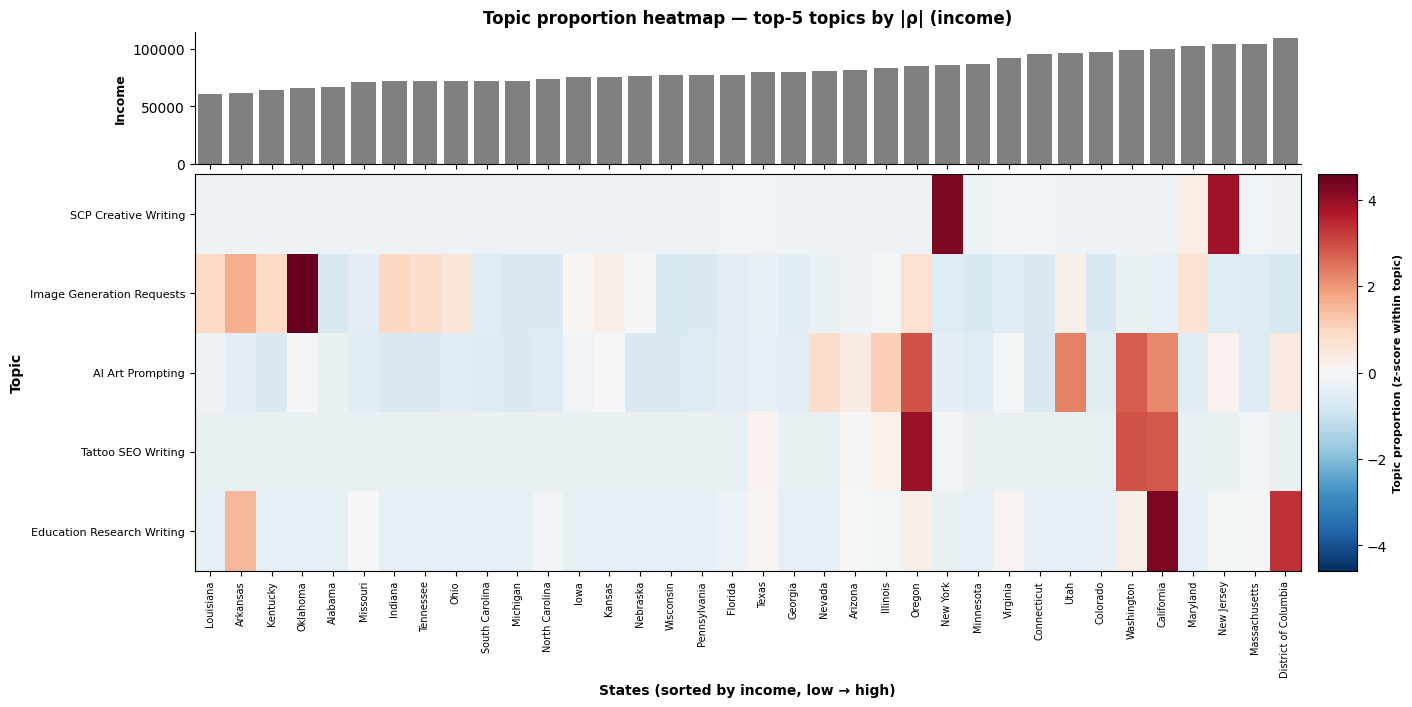

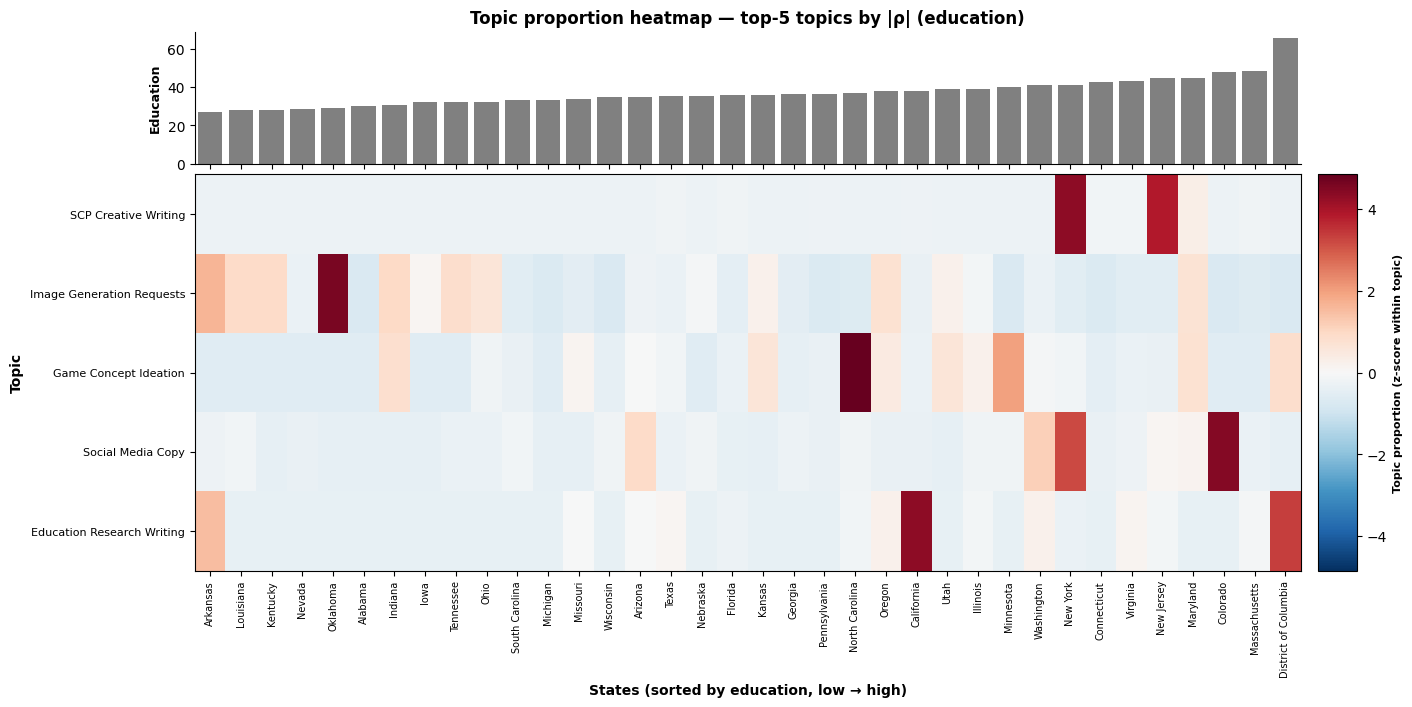

In [5]:
# Draw topic-level heatmaps from selected topics
OUT_DIR = SUMMARY_DIR / 'topic_demographic_relationship'
OUT_FIG_DIR = OUT_DIR / 'figures'
OUT_TAB_DIR = OUT_DIR / 'tables'
OUT_FIG_DIR.mkdir(parents=True, exist_ok=True)

def draw_heatmap(selected_df, covariate, heatmap_name):
    # Each cell = z-scored topic proportion (row-wise: deviation from this topic's national mean)
    # Enables cross-topic visual comparison; does not affect Spearman ρ (rank-invariant)
    topics = selected_df['topic'].tolist()
    topic_labels = selected_df['topic_label'].fillna(selected_df['topic']).tolist()
    d = merged_base[['state', covariate] + topics].copy().sort_values(covariate).reset_index(drop=True)

    state_names = d['state'].tolist()
    n_states = len(state_names)
    n_topics = len(topics)
    cov_vals = d[covariate].to_numpy()

    # topic x state matrix (row=topic, col=state sorted low->high by covariate)
    mat_raw = d[topics].T.to_numpy()   # shape: (n_topics, n_states)
    # Row-wise z-score: deviation of each state from this topic's national average
    row_mean = mat_raw.mean(axis=1, keepdims=True)
    row_std  = mat_raw.std(axis=1, keepdims=True)
    mat = (mat_raw - row_mean) / np.where(row_std == 0, 1, row_std)

    # Two stacked panels sharing the state x-axis
    fig = plt.figure(figsize=(15, 7))
    gs = fig.add_gridspec(2, 2, height_ratios=[1, 3],
                          width_ratios=[28, 1], hspace=0.04, wspace=0.03)
    ax_cov  = fig.add_subplot(gs[0, 0])
    ax_heat = fig.add_subplot(gs[1, 0], sharex=ax_cov)
    ax_cbar = fig.add_subplot(gs[1, 1])

    # -- Top panel: covariate value per state (bar chart) --
    ax_cov.bar(np.arange(n_states), cov_vals, color='#555555', alpha=0.75, width=0.8)
    ax_cov.set_ylabel(covariate.capitalize(), fontweight='bold', fontsize=9)
    ax_cov.set_title(
        f'Topic proportion heatmap — top-5 topics by |ρ| ({covariate})',
        fontweight='bold'
    )
    plt.setp(ax_cov.get_xticklabels(), visible=False)
    ax_cov.set_xlim(-0.5, n_states - 0.5)
    for sp in ['top', 'right']:
        ax_cov.spines[sp].set_visible(False)

    # -- Bottom panel: topic proportion heatmap (pcolormesh for data-coord alignment) --
    x_edges = np.arange(n_states + 1) - 0.5
    y_edges = np.arange(n_topics + 1) - 0.5
    abs_max = np.nanmax(np.abs(mat))
    im = ax_heat.pcolormesh(x_edges, y_edges, mat, cmap='RdBu_r', shading='flat',
                            vmin=-abs_max, vmax=abs_max)
    ax_heat.invert_yaxis()  # first topic at top
    ax_heat.set_yticks(np.arange(n_topics))
    ax_heat.set_yticklabels(topic_labels, fontsize=8)
    ax_heat.set_xticks(np.arange(n_states))
    ax_heat.set_xticklabels(state_names, rotation=90, fontsize=7)
    ax_heat.set_ylabel('Topic', fontweight='bold')
    ax_heat.set_xlabel(
        f'States (sorted by {covariate}, low → high)', fontweight='bold'
    )

    fig.colorbar(im, cax=ax_cbar)
    ax_cbar.set_ylabel('Topic proportion (z-score within topic)', fontweight='bold', fontsize=8)

    fig.savefig(OUT_FIG_DIR / heatmap_name, dpi=220, bbox_inches='tight')
    plt.show()


draw_heatmap(sel_income, 'income', 'heatmap_income_top5_topics.png')
draw_heatmap(sel_edu, 'education', 'heatmap_education_top5_topics.png')

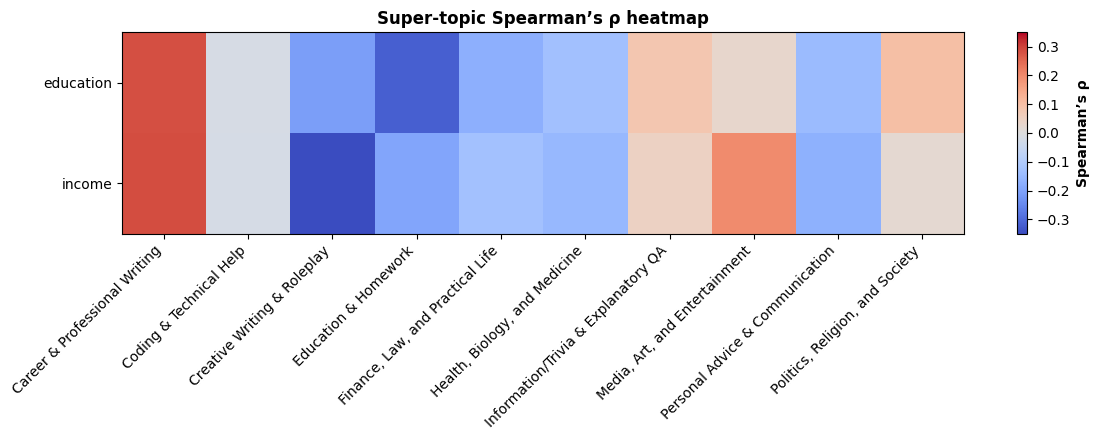

Saved super-topic ρ heatmap.


In [6]:
# Super-topic Spearman’s ρ heatmap (rows=covariate, cols=super-topic category)
OUT_DIR = SUMMARY_DIR / 'topic_demographic_relationship'
OUT_FIG_DIR = OUT_DIR / 'figures'
OUT_FIG_DIR.mkdir(parents=True, exist_ok=True)

# U1: super-topic rho heatmap (rows=covariate, cols=super-topic)
piv = super_corr.pivot(index='covariate', columns='super_topic', values='spearman_rho')
fig, ax = plt.subplots(figsize=(12, 4.5))
im = ax.imshow(piv.to_numpy(), aspect='auto', cmap='coolwarm', vmin=-max(abs(piv.min().min()), abs(piv.max().max())), vmax=max(abs(piv.min().min()), abs(piv.max().max())))
ax.set_xticks(np.arange(len(piv.columns)))
ax.set_xticklabels(piv.columns, rotation=45, ha='right')
ax.set_yticks(np.arange(len(piv.index)))
ax.set_yticklabels(piv.index)
ax.set_title('Super-topic Spearman’s ρ heatmap', fontweight='bold')
cb = fig.colorbar(im, ax=ax)
cb.set_label('Spearman’s ρ', fontweight='bold')
plt.tight_layout()
fig.savefig(OUT_FIG_DIR / 'U1_super_topic_rho_heatmap.png', dpi=220)
plt.show()
print('Saved super-topic ρ heatmap.')


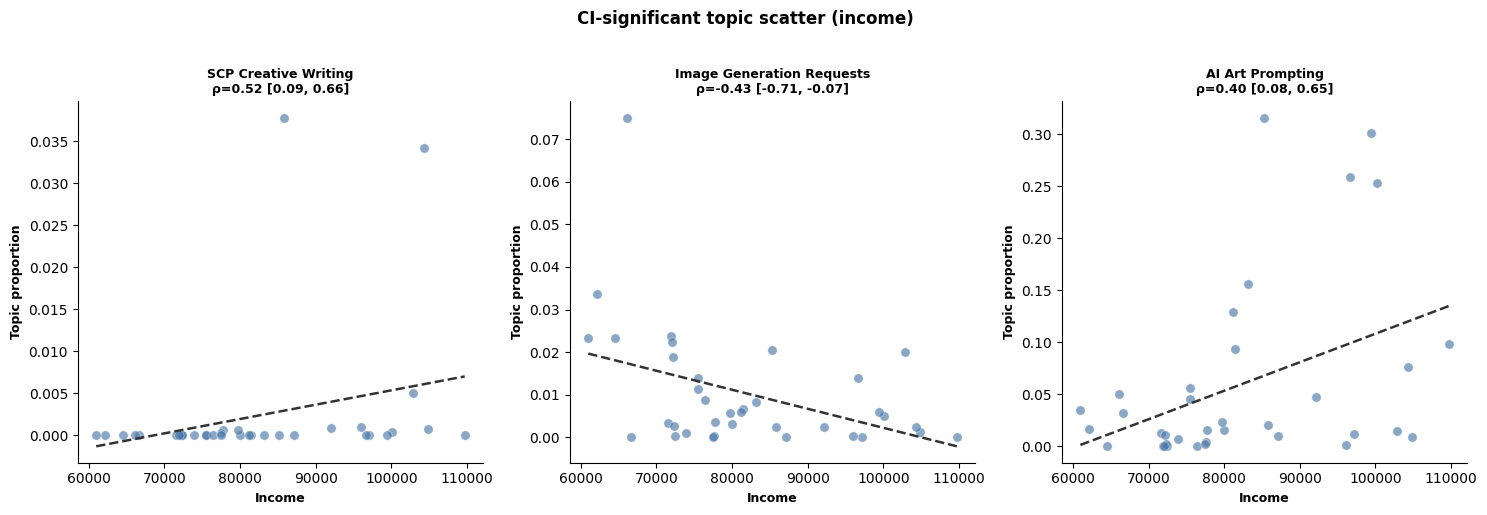

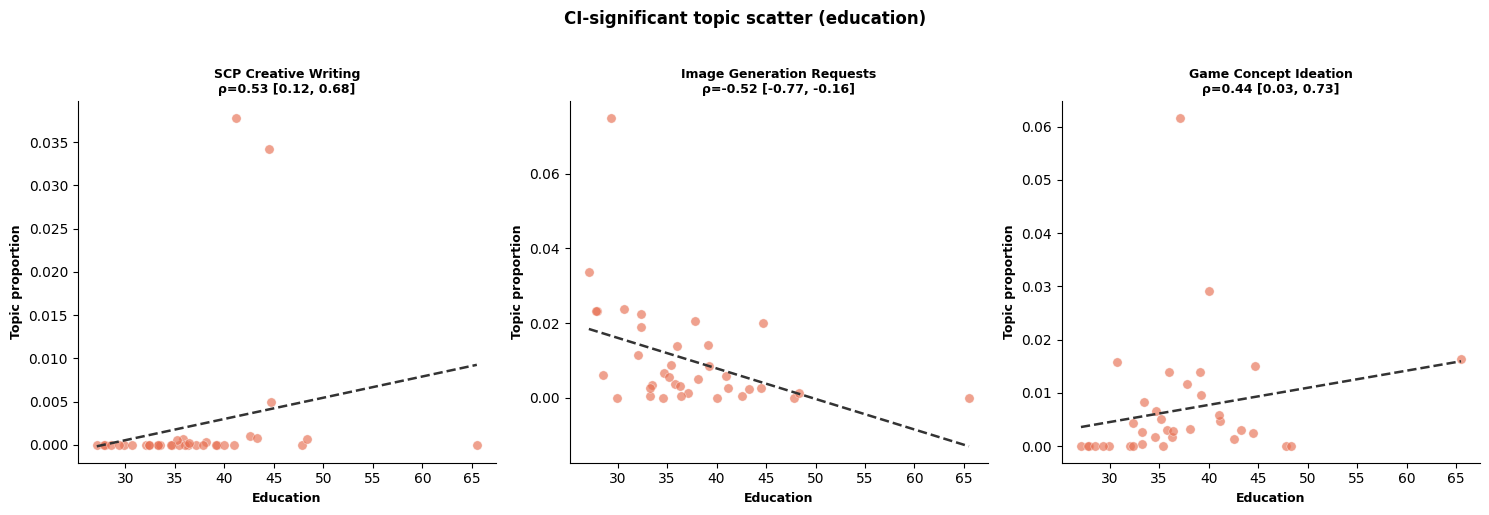

Saved super-topic/topic scatter figures to /Users/faylong/Library/Mobile Documents/com~apple~CloudDocs/School Works/EN.601.6672 NLP for computational social science/course-project/wildchat-demographics-analysis/results/summary/topic_demographic_relationship/figures


In [7]:
# CI-significant topic scatter — top-3 per covariate, one figure each
OUT_DIR = SUMMARY_DIR / 'topic_demographic_relationship'
OUT_FIG_DIR = OUT_DIR / 'figures'
OUT_FIG_DIR.mkdir(parents=True, exist_ok=True)

# T4: CI-significant topic scatter panels — top-3 per covariate, one figure each
cov_configs = [
    ('income',    '#4C78A8', 'T4a_income_scatter.png'),
    ('education', '#E76F51', 'T4b_education_scatter.png'),
]

sig = (
    topic_corr[topic_corr['ci_sig']]
    .assign(abs_rho=lambda df: df['spearman_rho'].abs())
    .sort_values('abs_rho', ascending=False)
    .groupby('covariate', group_keys=False)
    .head(3)
    .sort_values(['covariate', 'abs_rho'], ascending=[True, False])
    .reset_index(drop=True)
)

for cov_name, color, fname in cov_configs:
    sub = sig[sig['covariate'] == cov_name].reset_index(drop=True)
    ncol = len(sub)
    if ncol == 0:
        print(f'No CI-significant topics for {cov_name}')
        continue

    fig, axes = plt.subplots(1, ncol, figsize=(5 * ncol, 5), squeeze=False)

    for col_i, (_, r) in enumerate(sub.iterrows()):
        ax = axes[0][col_i]
        t = r['topic']
        if t not in merged_base.columns:
            ax.axis('off')
            continue
        x = merged_base[cov_name].to_numpy()
        y = merged_base[t].to_numpy()

        ax.scatter(x, y, color=color, alpha=0.65, s=45, edgecolors='white', linewidths=0.4)

        # OLS regression line
        mask = ~(np.isnan(x) | np.isnan(y))
        xm, ym = x[mask], y[mask]
        slope, intercept = np.polyfit(xm, ym, 1)
        x_line = np.linspace(xm.min(), xm.max(), 200)
        ax.plot(x_line, slope * x_line + intercept, color='#333333',
                linewidth=1.8, linestyle='--')

        ax.set_xlabel(cov_name.capitalize(), fontweight='bold', fontsize=9)
        ax.set_ylabel('Topic proportion', fontweight='bold', fontsize=9)
        ci_str = f'[{r["ci_low"]:.2f}, {r["ci_high"]:.2f}]'
        ax.set_title(f'{r["topic_label"]}\nρ={r["spearman_rho"]:.2f} {ci_str}',
                     fontweight='bold', fontsize=9)
        for sp in ['top', 'right']:
            ax.spines[sp].set_visible(False)

    plt.suptitle(f'CI-significant topic scatter ({cov_name})', fontweight='bold', y=1.02)
    plt.tight_layout()
    fig.savefig(OUT_FIG_DIR / fname, dpi=220, bbox_inches='tight')
    plt.show()

print('Saved super-topic/topic scatter figures to', OUT_FIG_DIR)


### 3.4 Conclusion
A consistent set of topics — SCP Creative Writing, Image Generation Requests, and AI Art Prompting (income) / Game Concept Ideation (education) — shows reliable demographic signal across both the Spearman ρ analysis and the heatmap visualization. The z-scored heatmap confirms clear geographic gradients for the top-5 topics when states are sorted by covariate level. The super-topic ρ heatmap indicates that Creative Writing & Roleplay and Media, Art & Entertainment are the most demographically differentiated content categories. These findings are cross-validated in Section 4 with log-odds analysis.

## 4. Supplementary Log-Odds Analysis

### 4.1 Introduction
Log-odds provides a complementary binary-contrast view of demographic-topic associations. States are split at the median covariate value into high / low groups, and for each merged topic we compute log(mean\_proportion\_high / mean\_proportion\_low). This cross-validates the Spearman findings: CI-significant topics should also rank highly by absolute log-odds. Topics significant in the Spearman analysis are highlighted with ★ in the figures.

### 4.2 Metrics and Methods
- **Groups**: states split at the median covariate value (income or education) into high / low halves.
- **Log-odds**: computed in-notebook from `merged_base` — `log((mean_high + ε) / (mean_low + ε))` with `ε = 1e-6` to avoid division by zero.
- **Consistency**: uses the same merged topic proportions as the Spearman analysis (identical topic definitions and per-state values).
- **Highlighting**: CI-significant topics from the Spearman bootstrap analysis are marked with ★ and rendered in the primary color; all other topics appear in grey. This makes it easy to see whether the Spearman findings hold under a binary-contrast framing.

In [8]:
# Recalculate log-odds directly from merged topic proportions for consistency
# with the Spearman analysis (same merged_base, same topic labels).
# States are split into high / low groups at the median covariate value.
EPS = 1e-6   # smoothing to avoid log(0) for sparse topics

log_dfs = {}
for cov in ['income', 'education']:
    median_val = merged_base[cov].median()
    high_states = merged_base[merged_base[cov] >= median_val]
    low_states  = merged_base[merged_base[cov] <  median_val]

    rows = []
    for t in topic_cols:          # topic_cols are merged label strings
        g1 = high_states[t].dropna().mean()
        g2 = low_states[t].dropna().mean()
        lo = np.log((g1 + EPS) / (g2 + EPS))
        rows.append({
            'topic_label': t,
            'log_odds':    lo,
            'group_high_mean': g1,
            'group_low_mean':  g2,
            'direction': f'high_{cov}' if lo > 0 else f'low_{cov}',
        })

    df = (pd.DataFrame(rows)
          .assign(abs_log_odds=lambda d: d['log_odds'].abs())
          .sort_values('abs_log_odds', ascending=False)
          .reset_index(drop=True))
    log_dfs[cov] = df

log_income = log_dfs['income']
log_edu    = log_dfs['education']

print('Top-15 topic log-odds — income (high vs low income states)')
display(log_income[['topic_label', 'log_odds', 'group_high_mean', 'group_low_mean', 'direction']].head(15))

print('\nTop-15 topic log-odds — education (high vs low education states)')
display(log_edu[['topic_label', 'log_odds', 'group_high_mean', 'group_low_mean', 'direction']].head(15))


Top-15 topic log-odds — income (high vs low income states)


,topic_label,log_odds,group_high_mean,group_low_mean,direction
0,Fantasy Crossover Fanfiction,-8.427156,0.000000,0.004568,low_income
1,Tattoo SEO Writing,7.960802,0.002865,0.000000,high_income
2,SCP Creative Writing,4.535416,0.004466,0.000047,high_income
3,Short Reply Generation,3.536052,0.003030,0.000087,high_income
4,Warcraft Fan Fiction,-3.488243,0.000034,0.001141,low_income
5,Image Prompt Expansion,3.244449,0.001604,0.000062,high_income
6,Wizard101 Fan Fiction,-2.824460,0.000062,0.001057,low_income
7,DDLC Fan Fiction,-2.685453,0.002044,0.029983,low_income
8,Brand Name Ideation,-2.508114,0.000864,0.010626,low_income
9,Fetish Comedy Stories,2.270289,0.043349,0.004476,high_income



Top-15 topic log-odds — education (high vs low education states)


,topic_label,log_odds,group_high_mean,group_low_mean,direction
0,Fantasy Crossover Fanfiction,-8.427156,0.000000,0.004568,low_education
1,SCP Creative Writing,4.205772,0.004447,0.000065,high_education
2,Warcraft Fan Fiction,-3.488243,0.000034,0.001141,low_education
3,Short Reply Generation,3.473009,0.003025,0.000093,high_education
4,Image Prompt Expansion,3.244449,0.001604,0.000062,high_education
5,Cast List Generation,-2.994079,0.000453,0.009070,low_education
6,Cartoon Crossover Concepts,-2.909357,0.000400,0.007355,low_education
7,Wizard101 Fan Fiction,-2.824460,0.000062,0.001057,low_education
8,Brand Name Ideation,2.702047,0.010769,0.000721,high_education
9,DDLC Fan Fiction,-2.526613,0.002370,0.029657,low_education


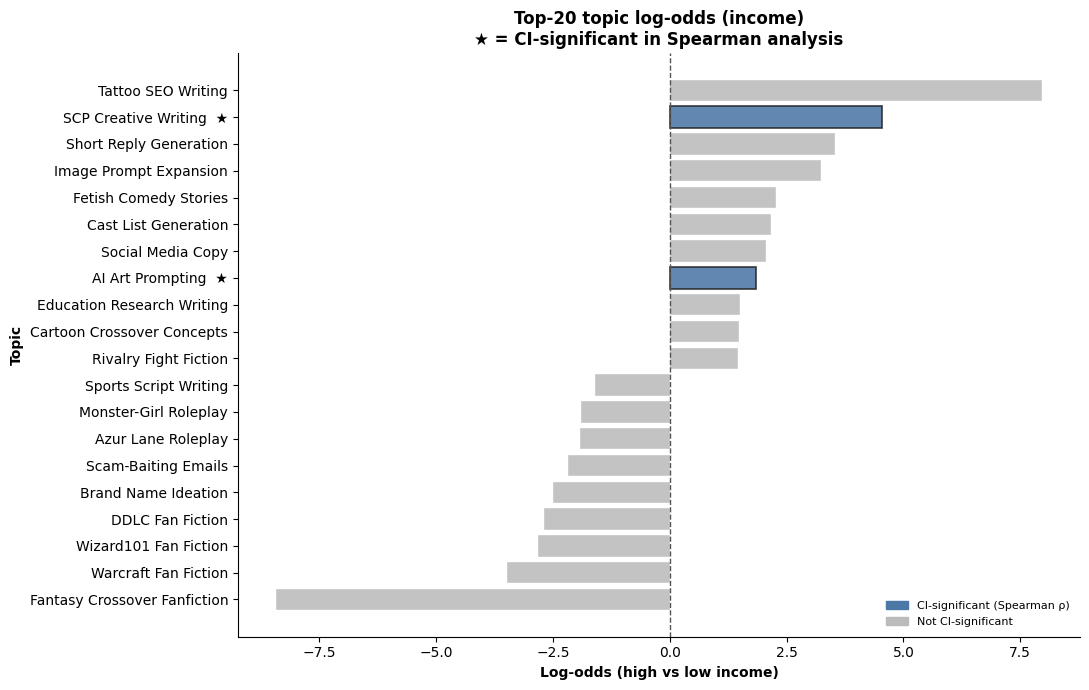

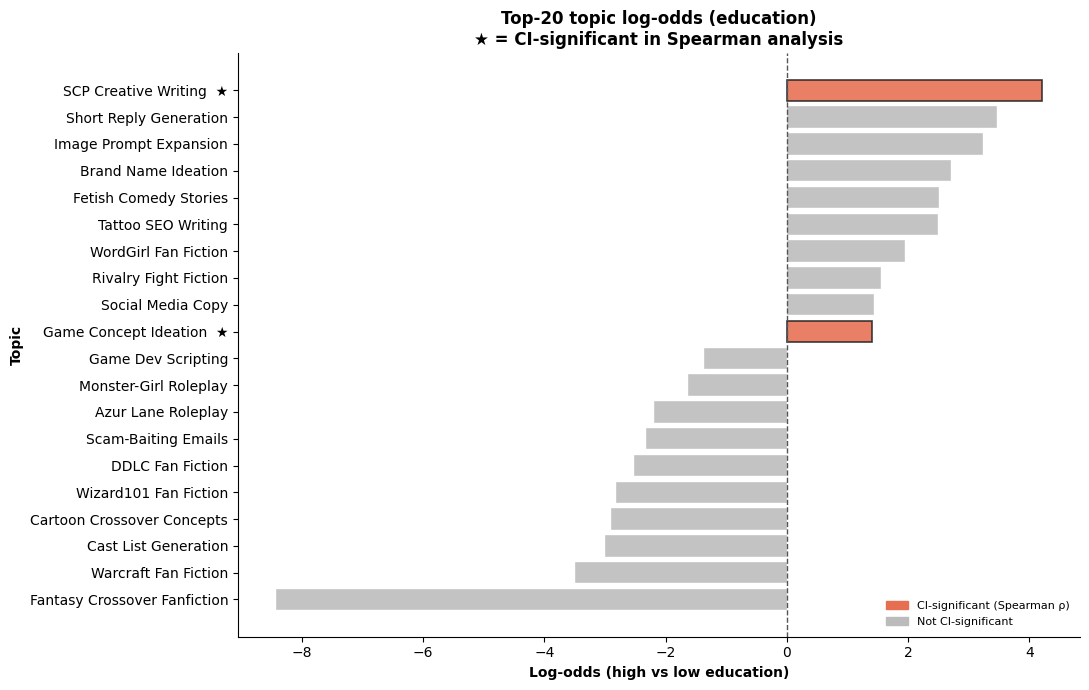

Saved log-odds figures to /Users/faylong/Library/Mobile Documents/com~apple~CloudDocs/School Works/EN.601.6672 NLP for computational social science/course-project/wildchat-demographics-analysis/results/summary/topic_demographic_relationship/figures


In [9]:
# Draw log-odds summary figures and save
OUT_DIR = SUMMARY_DIR / 'topic_demographic_relationship'
OUT_FIG_DIR = OUT_DIR / 'figures'
OUT_FIG_DIR.mkdir(parents=True, exist_ok=True)

import matplotlib.patches as mpatches

for df, cov, fname, color in [
    (log_income, 'income',    'log_odds_income.png',    '#4C78A8'),
    (log_edu,    'education', 'log_odds_education.png', '#E76F51'),
]:
    d = df.sort_values('abs_log_odds', ascending=False).head(20).sort_values('log_odds').copy()

    # Topics that are CI-significant in the Spearman analysis for this covariate
    ci_sig_topics = set(
        topic_corr[(topic_corr['covariate'] == cov) & topic_corr['ci_sig']]['topic_label']
    )

    bar_colors = [color if t in ci_sig_topics else '#bbbbbb' for t in d['topic_label']]
    edge_colors = ['#222222' if t in ci_sig_topics else 'white' for t in d['topic_label']]
    linewidths  = [1.2 if t in ci_sig_topics else 0.3 for t in d['topic_label']]
    # Add ★ to labels of CI-significant topics
    labels = [f'{t}  ★' if t in ci_sig_topics else t for t in d['topic_label']]

    fig, ax = plt.subplots(figsize=(11, 7))
    ax.barh(labels, d['log_odds'], color=bar_colors, alpha=0.88,
            edgecolor=edge_colors, linewidth=linewidths)
    ax.axvline(0, linestyle='--', linewidth=1, color='#555555')
    ax.set_xlabel(f'Log-odds (high vs low {cov})', fontweight='bold')
    ax.set_ylabel('Topic', fontweight='bold')
    ax.set_title(f'Top-20 topic log-odds ({cov})\n★ = CI-significant in Spearman analysis',
                 fontweight='bold')

    # Legend
    ax.legend(handles=[
        mpatches.Patch(color=color,     label='CI-significant (Spearman ρ)'),
        mpatches.Patch(color='#bbbbbb', label='Not CI-significant'),
    ], fontsize=8, frameon=False, loc='lower right')

    for sp in ['top', 'right']:
        ax.spines[sp].set_visible(False)
    plt.tight_layout()
    fig.savefig(OUT_FIG_DIR / fname, dpi=220, bbox_inches='tight')
    plt.show()

print('Saved log-odds figures to', OUT_FIG_DIR)


## 5. Conclusion
The log-odds rankings are broadly consistent with the Spearman ρ results: CI-significant topics (★) tend to appear near the top of the log-odds charts, providing independent cross-validation from a binary-contrast perspective. Together, Spearman ρ with 95% bootstrap CI, z-scored heatmaps, OLS scatter panels, super-topic ρ overview, and log-odds form a coherent multi-perspective evidence base for the demographic-topic associations.